<a href="https://colab.research.google.com/github/Saransh-Basu-01/50-Ml-Projects-to-understand-LLMs/blob/main/Project_10_Sequential_Number_Cosine_Similarity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Part_1:Token counts of numbers

## Task_1:
- Import the GPT-2 model and its tokenizer, and extract the embed
dings matrix from the model (you’ll start using the embeddings in
Part 3).In a for-loop over integers from-1000 to +1000, convert each
number to a string, tokenize, and store the token indices and the
number of tokens. Create a scatter plot of the encoded number bythe number of tokens, as in Figure 3.14.

In [2]:
from transformers import AutoTokenizer,GPT2Model
tokenizer_G = AutoTokenizer.from_pretrained('gpt2')
model = GPT2Model.from_pretrained('gpt2')

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  548MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

In [3]:
embeddings=model.wte.weight.detach()

In [9]:
numbers=np.arange(-1000,1001)
num_tokens=np.zeros(len(numbers),dtype=int)
token_idx=[]

In [10]:
for i in range(len(numbers)):
  str_i=str(numbers[i])
  token_i=tokenizer_G.encode(str_i)
  token_idx.append(token_i)
  num_tokens[i]=len(token_i)


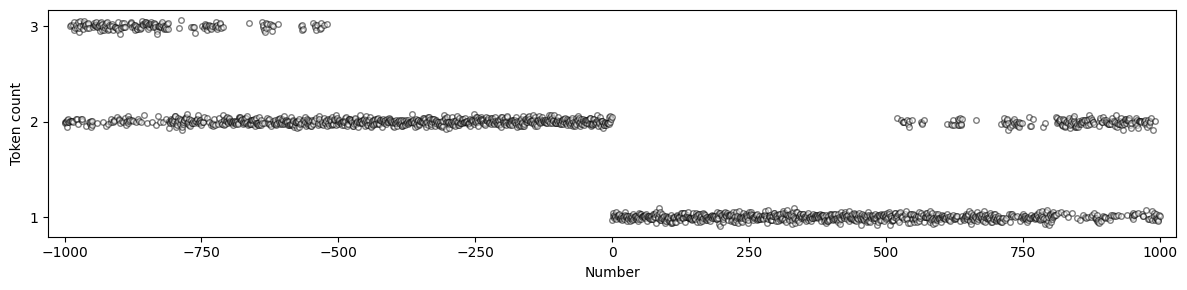

In [19]:
plt.figure(figsize=(12,3))
plt.plot(numbers,num_tokens+np.random.normal(0,.03,len(numbers)),'ko',markerfacecolor='w',markersize=4,alpha=.5)
plt.gca().set(xlabel='Number',ylabel='Token count',yticks=np.unique(num_tokens),
              xlim=[numbers[0]-30,numbers[-1]+30])

plt.tight_layout()
plt.show()

## Task_2
- Write code to create Figure 3.15, which plots the numerical values
of the token indices. Blue circles correspond to the first token in the
number, green squares correspond to the second token in the number,
and red triangles correspond to the third token in the number.

/tmp/ipykernel_920/4225531056.py:26: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


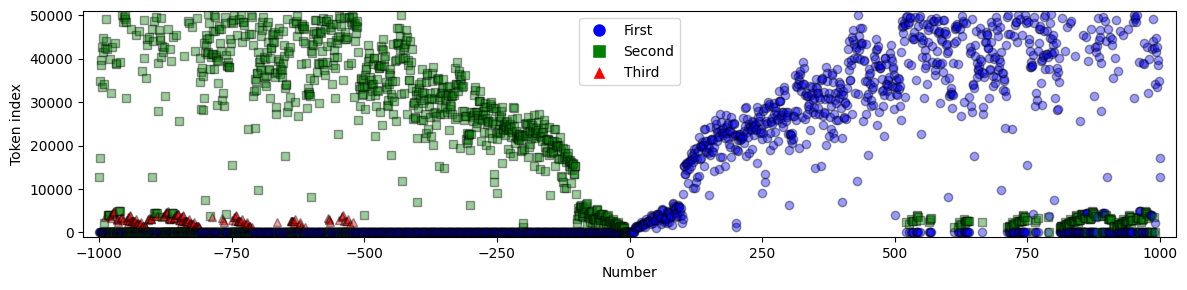

In [22]:
plt.figure(figsize=(12,3))
colord = 'bgr'
shape = 'os^'

# loop over tokens
for i in range(len(numbers)):

  # extract the token indices for this number
  t = token_idx[i]

  # plot them
  for ti in range(len(t)):
    plt.plot(numbers[i],t[ti],'k',marker=shape[ti],markerfacecolor=colord[ti],
             markersize=6,alpha=.4,linewidth=.4)


# hacky legend solution (plot with alpha=0)
for i in range(3):
  plt.plot(0,0,'w',marker=shape[i],markerfacecolor=colord[i],
             markersize=10,alpha=0,linewidth=.5,label=['First','Second','Third'][i])
h = plt.legend()
for e in h.legend_handles: e.set_alpha(1)

plt.gca().set(xlabel='Number',ylabel='Token index',ylim=[-1000,51000],xlim=[numbers[0]-30,numbers[-1]+30])

plt.tight_layout()
plt.show()